# ***Razón Estandarizada de Morbilidad [Atlántico]***

En el caso del departamento del **Atlántico**, la Razón Estandarizada de Morbilidad (REM) permite evaluar si la carga de dengue registrada supera o se encuentra por debajo de la esperada según la tasa departamental. Este indicador evidencia el comportamiento relativo del riesgo en el territorio y ayuda a identificar si sus municipios presenta un exceso de morbilidad frente al promedio del departamento, lo que resulta clave para orientar estrategias locales de prevención y control.

$$
REM_{Atlántico} = \frac{O_{Atlántico}}{E_{Atlántico}}
$$

donde:  
- $ O_{Atlántico} $= casos observados en el departamento,  
- $ E_{Atlántico} $ = casos esperados según la tasa departamental de incidencia.


In [1]:
# [Configuración] Imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode

In [2]:
# [Configuración] Lectura de archivos

## Archivos CSV de REM
rem_clasico = pd.read_csv(r"REM/REM_Clasico_ATL.csv")
rem_grave = pd.read_csv(r"REM/REM_Grave_ATL.csv")
rem_periodo_grave = pd.read_csv(r"REM/REM_PERIODO_Grave_ATL.csv")
rem_periodo_clasico = pd.read_csv(r"REM/REM_PERIODO_Clasico_ATL.csv")

## Archivo shapefile de Muncipios del Atlántico
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'}) 
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

In [3]:
# [Funciones] Graficar panel de mapas REM por años.

def graficar_panel_rem_atlantico(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en Atlántico por años,
    cada uno con su escala individual.
    """
    # Normalizar municipios en CSV
    df["municipio"] = df["municipio"].str.upper().str.strip().map(unidecode)

    # Normalizar municipios en shapefile
    shp["municipio"] = shp["municipio"].str.upper().str.strip().map(unidecode)

    anios = sorted(df["año"].unique())

    ncols = 4
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]

        df_anio = df[df["año"] == anio]

        # Merge: shapefile + datos del año
        gdf_anio = shp.merge(df_anio, left_on="municipio", right_on="municipio", how="left")
        gdf_anio["REM"] = gdf_anio["REM"].fillna(0)

        vmin, vmax = gdf_anio["REM"].min(), gdf_anio["REM"].max()

        gdf_anio.plot(
            column="REM",
            cmap="Blues",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "REM"}
        )

        ax.set_title(f"Año {anio}", fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    titulo = f"REM del dengue {evento or 'general'} en Atlántico ({anios[0]}–{anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
# [Funciones] Graficar panel de mapas REM por periodos.

def graficar_periodos(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en el Atlántico por Periodos,
    cada uno con su escala individual.
    
    Parámetros:
        df (pd.DataFrame): datos con columnas [departamento, anio, rem].
        shp (gpd.GeoDataFrame): shapefile del Atlántico.
        evento (str, opcional): tipo de evento ("Clásico", "Grave", etc.).
    """


    df["municipio"] = df["municipio"].str.upper().str.strip()
    shp["municipio"] = shp["municipio"].str.upper().str.strip()

    
    anios = sorted(df["periodo"].unique())

    
    ncols = 2
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]
        df_anio = df[df["periodo"] == anio]
        gdf_anio = shp.merge(df_anio, left_on="municipio", right_on="municipio", how="left")
        gdf_anio["REM"] = gdf_anio["REM"].fillna(0)

        vmin = gdf_anio["REM"].min()
        vmax = gdf_anio["REM"].max()

        # Graficar mapa
        gdf_anio.plot(
            column="REM",
            cmap="Blues",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "REM"}
        )

        ax.set_title(str(anio), fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

  
    titulo = f"REM del dengue {evento or 'general'} en Colombia en los periodos ({anios[0]})–({anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()




## ***REM por Año***

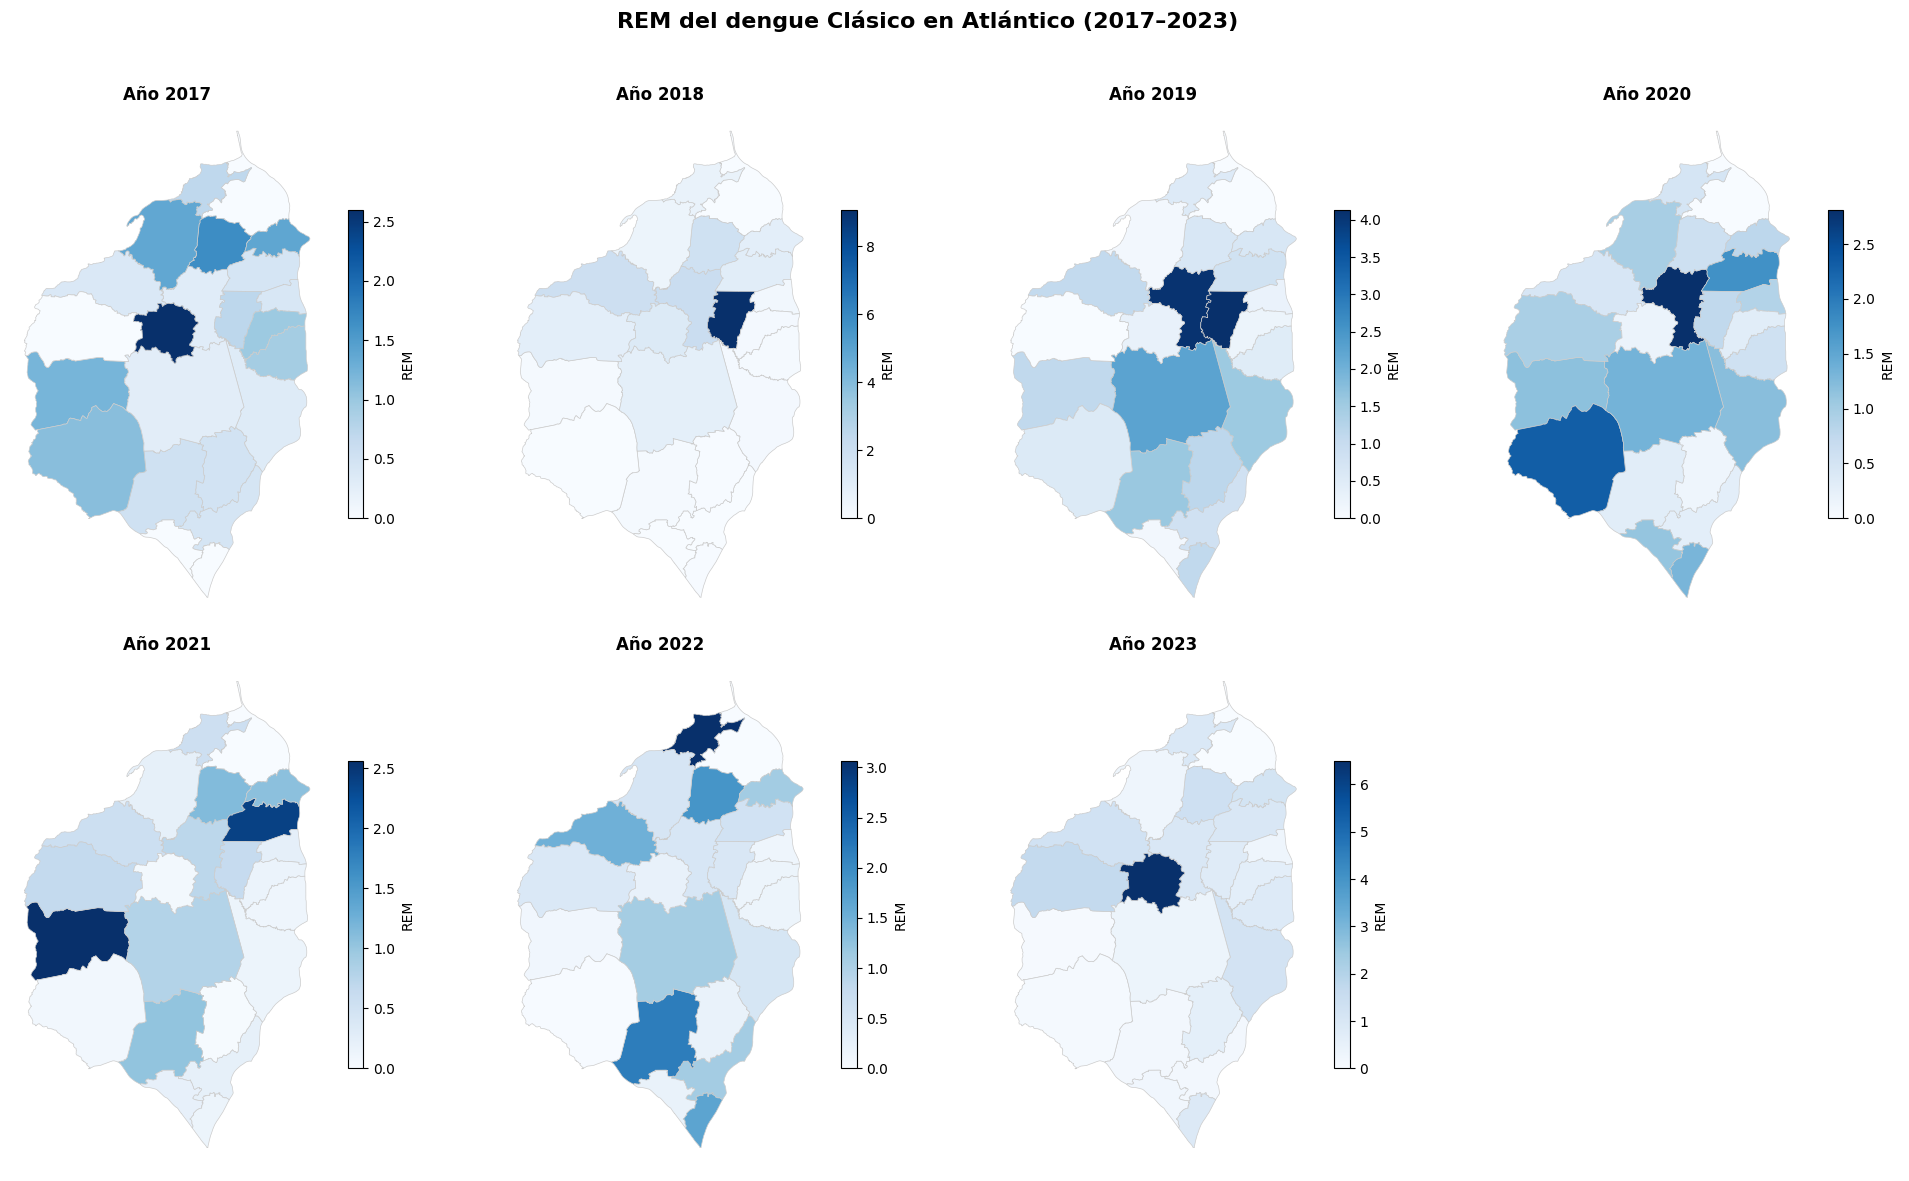

In [4]:
graficar_panel_rem_atlantico(rem_clasico, gdf, evento="Clásico")

Para el dengue clásico, se observa un pico especialmente elevado en **2018** y **2019**, con focos de alta concentración en municipios del área central, como **Baranoa** y **Polonuevo**, mientras que en **2020** la intensidad se desplaza hacia zonas del sur del departamento, como **Repelón**, sim embargo se mantiene la intensidad en **Baranoa**. Posteriormente, los años **2021** y **2022** evidencian una reducción relativa en los indicadores, aunque con recurrencias en municipios del norte, por ejemplo, **Puerto Colombia**. En **2023** se presenta nuevamente un repunte considerable, concentrado de forma muy marcada en **Usiacurí**, lo que indica un comportamiento localizado pero intenso.

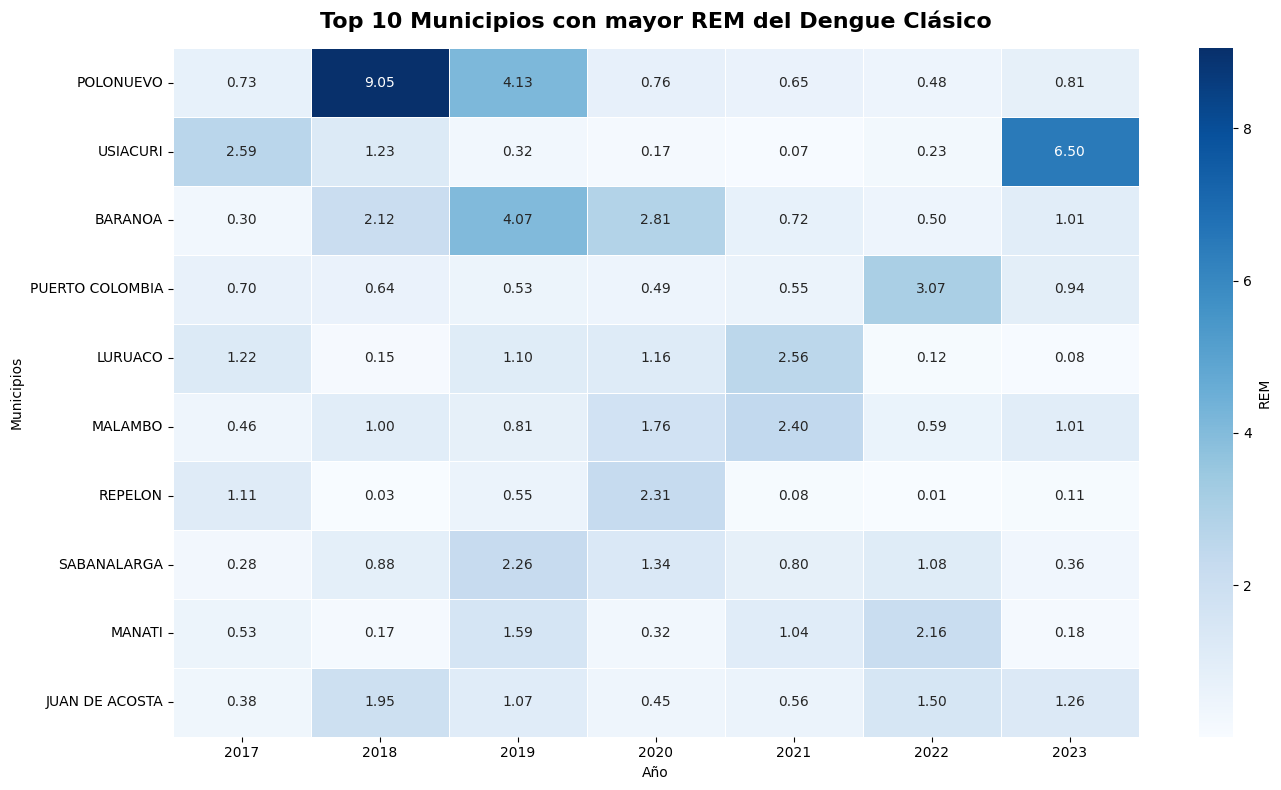

In [5]:
# === 1. Pivotear ===
tabla_clasico_rem = rem_clasico.pivot(
    index="municipio", 
    columns="año", 
    values="REM"
).fillna(0)

# === 2. Seleccionar top 10 departamentos con mayores valores de REM ===
top10_departamentos = (
    tabla_clasico_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_clasico_rem.loc[top10_departamentos]

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Blues",
    annot=True,
    fmt=".2f",              # <-- mostrar con 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Municipios con mayor REM del Dengue Clásico", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Municipios")
plt.tight_layout()
plt.show()


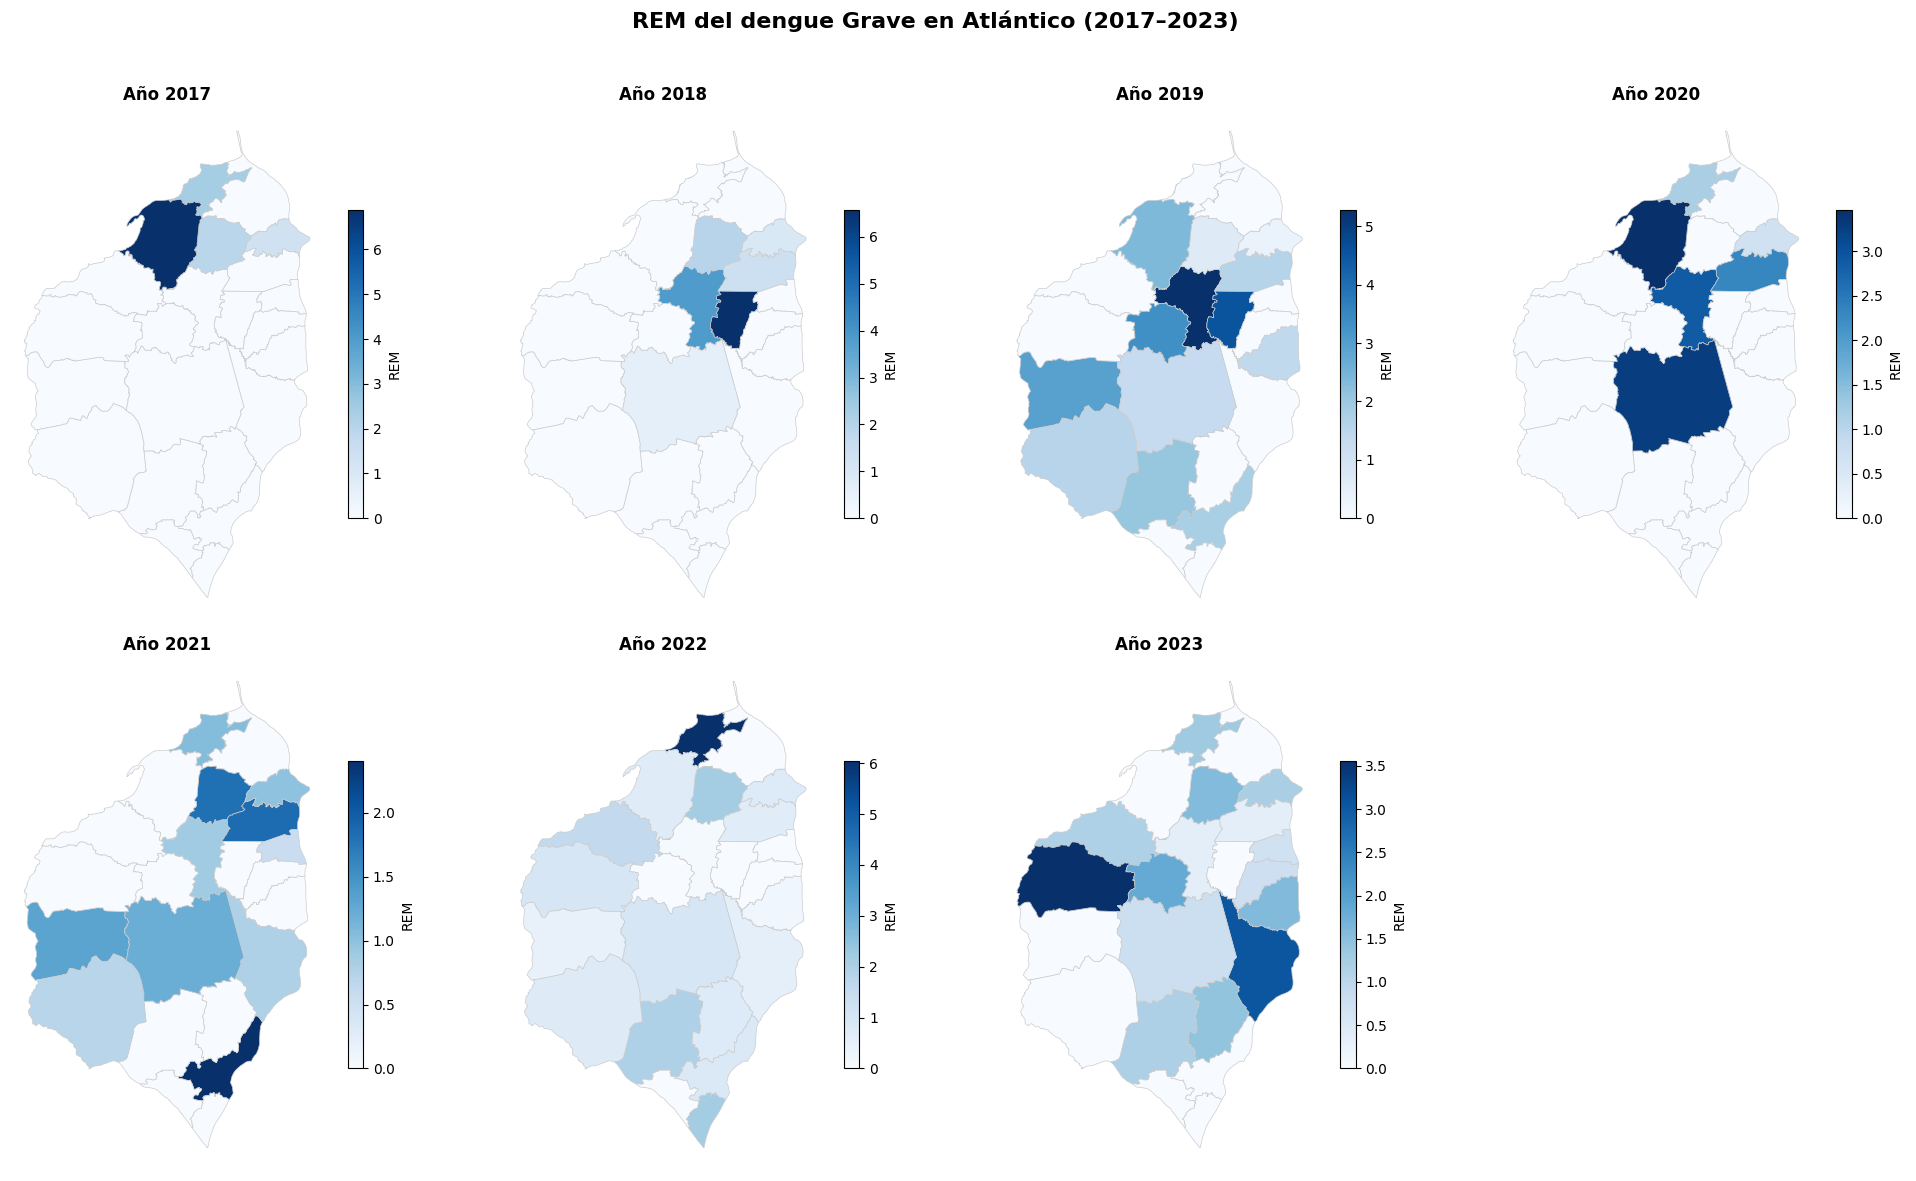

In [6]:
graficar_panel_rem_atlantico(rem_grave, gdf, evento="Grave")

En contraste al clásico, el dengue grave en el Atlántico mantiene valores más bajos en general, aunque con oscilaciones notables a lo largo del periodo total. En **2017** predominan las altas tasas en la zona norte,como en el municipio de **Tubará**, mientras que entre **2018** y **2020** los focos de mayor intensidad se desplazan hacia el centro del departamento, donde entre aquellos con mayor intensidad resaltan **Polonuevo**, **Baranoa**, **Tubará** y **Sabanalarga**. Durante el **2021** se registran valores moderados, con presencia en municipios del norte y sur, principalmente en **Campo de la Cruz**, mientras que en **2023** surge un aumento considerable en **Luruaco**, reflejando un patrón más focalizado que el del dengue clásico. 

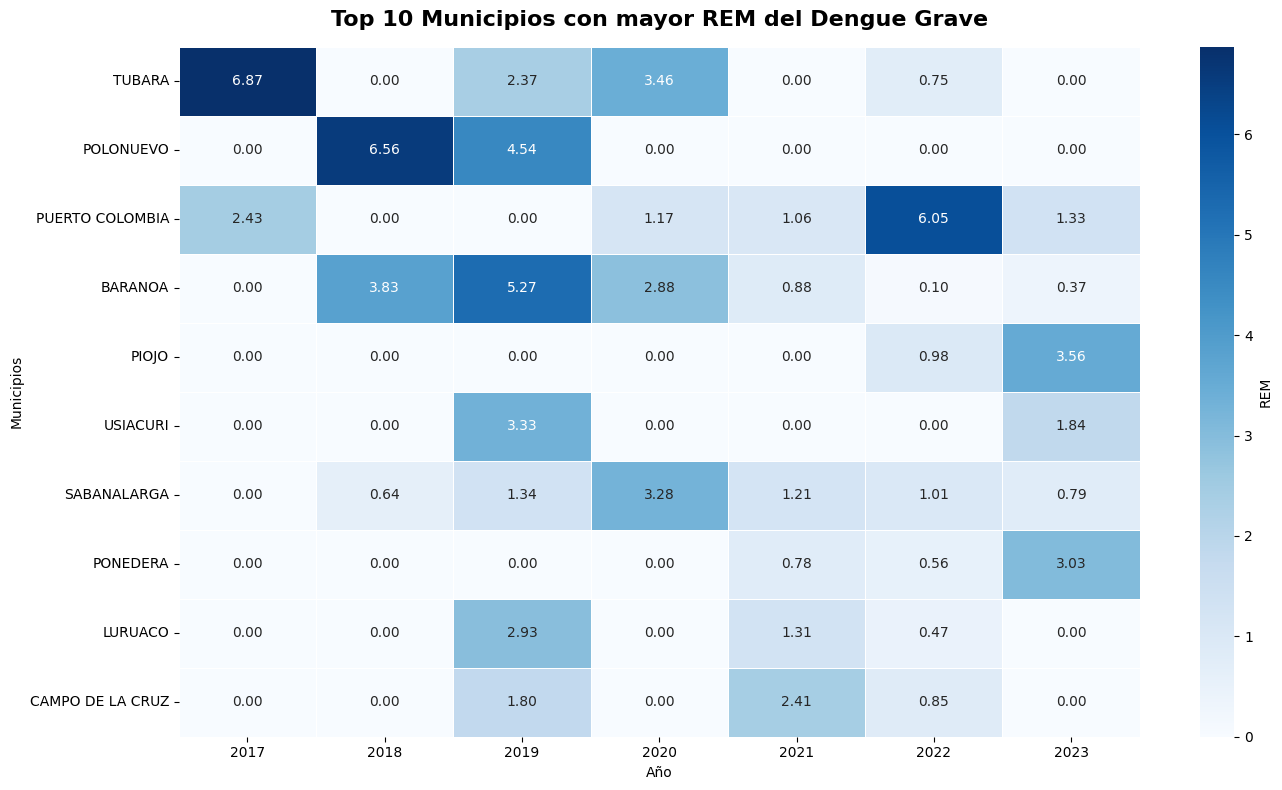

In [7]:
# === 1. Pivotear ===
tabla_clasico_rem = rem_grave.pivot(
    index="municipio", 
    columns="año", 
    values="REM"
).fillna(0)

# === 2. Seleccionar top 10 departamentos con mayores valores de REM ===
top10_departamentos = (
    tabla_clasico_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_clasico_rem.loc[top10_departamentos]

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Blues",
    annot=True,
    fmt=".2f",              # <-- mostrar con 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Municipios con mayor REM del Dengue Grave", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Municipios")
plt.tight_layout()
plt.show()


## ***REM por Periodo***

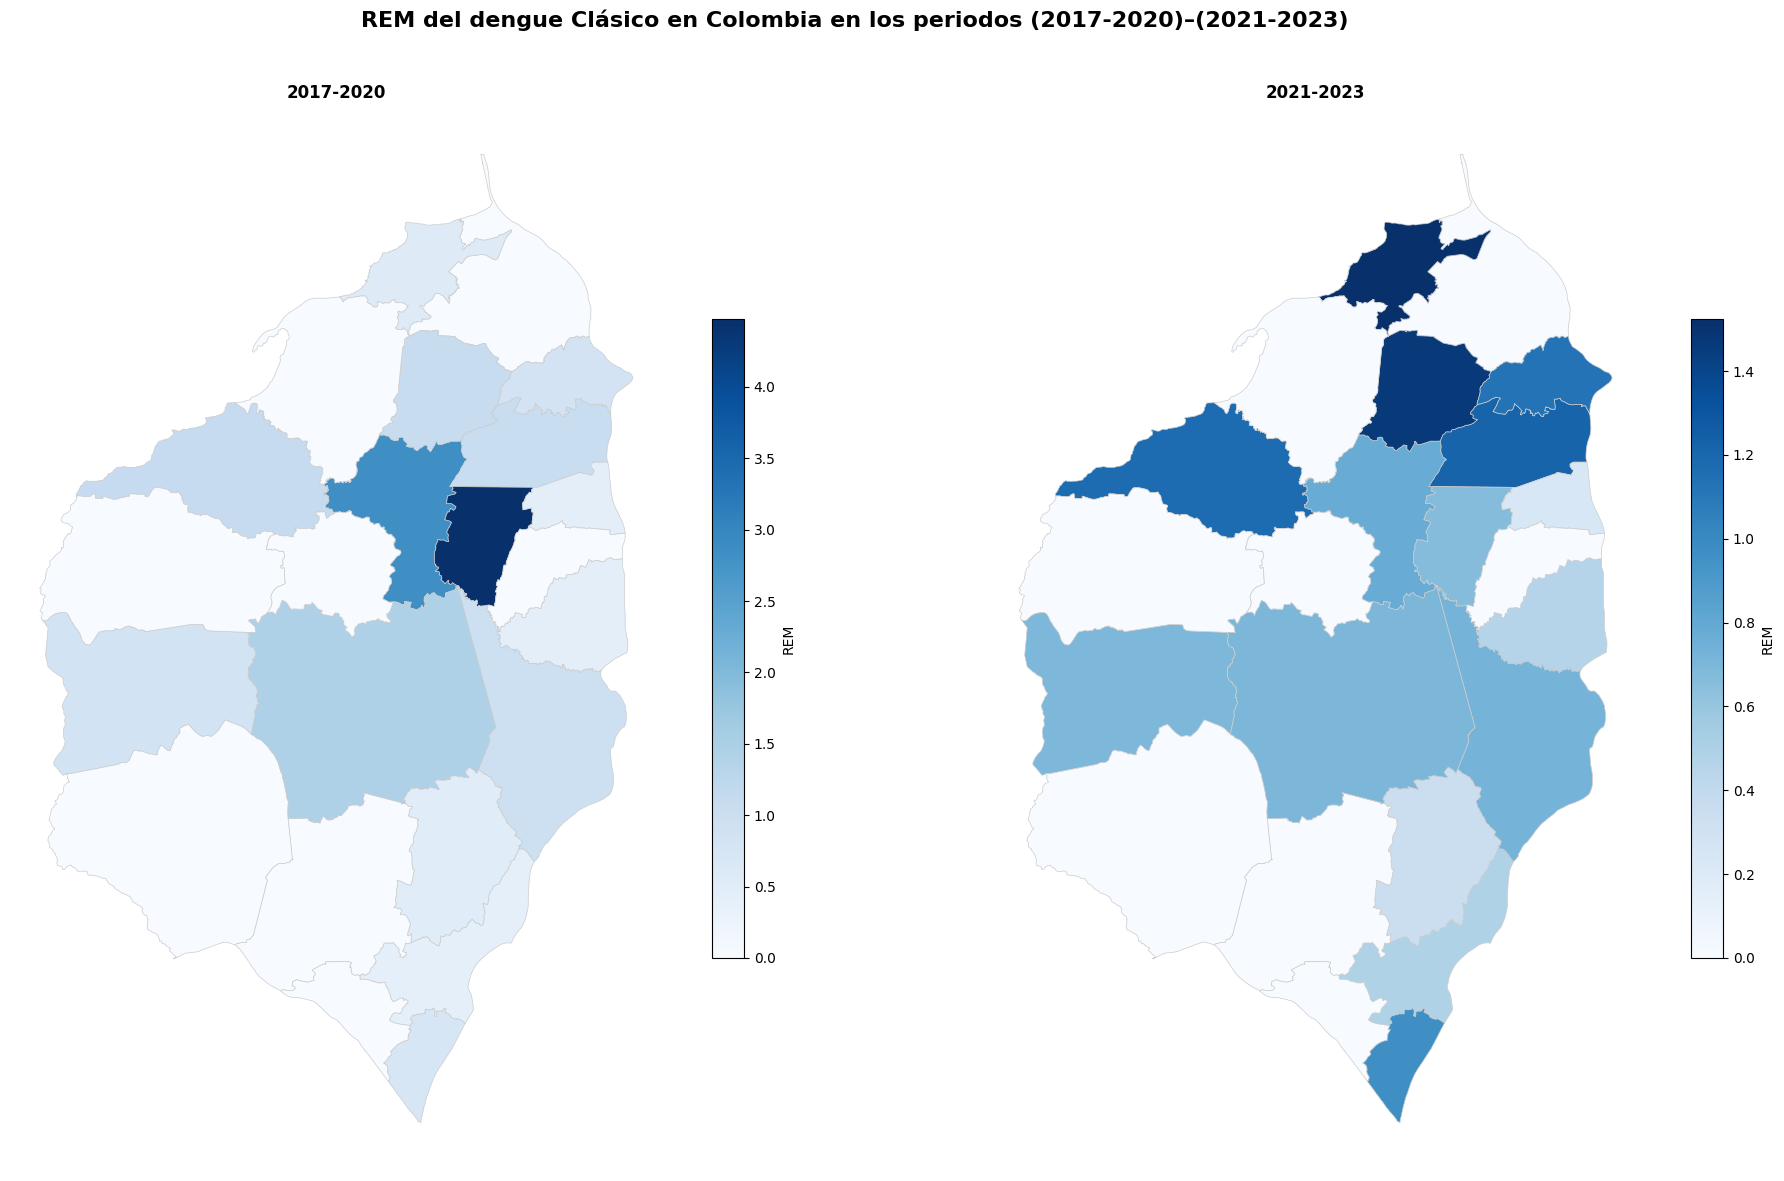

In [8]:
graficar_periodos(rem_periodo_clasico, gdf, evento="Clásico")

Durante el primer periodo **(2017–2020)**, se evidencia una alta concentración del riesgo en el centro del Atlántico, destacando municipios como **Baranoa** y **Polonuevo**, donde el REM supera ampliamente el promedio departamental. Estas zonas presentan un patrón de persistencia del dengue clásico, con intensidades que se extienden hacia áreas vecinas como **Sabanalarga** o **Juan de Acosta**. En el segundo periodo **(2021–2023)**, el comportamiento cambia notablemente: ahora resaltan las zonas del norte y la franja costera, como **Puerto Colombia** y **Galapa**, presentan mayores valores de **REM**, mientras que el centro del departamento reduce sus indices del periodo anterior.



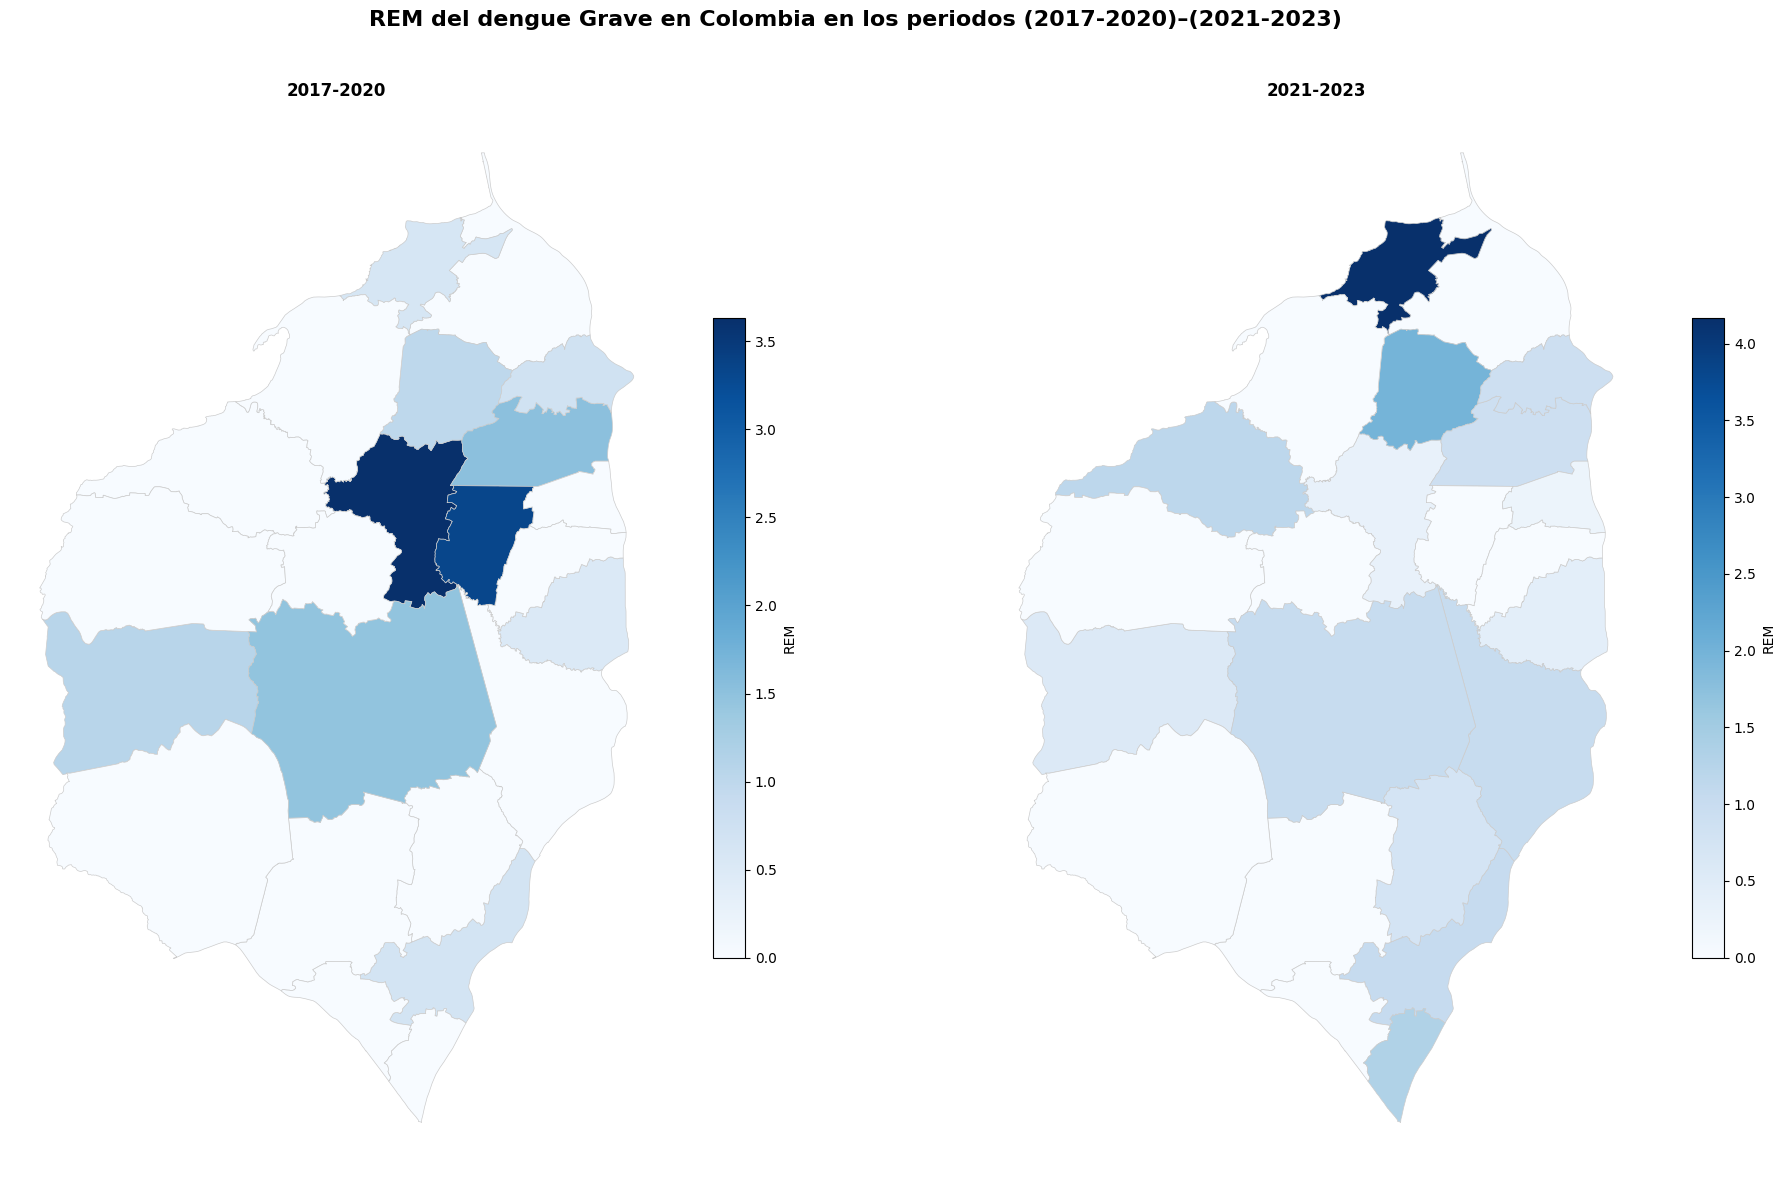

In [9]:
graficar_periodos(rem_periodo_grave, gdf, evento="Grave")

En el primer periodo **(2017–2020)**, el dengue grave muestra valores elevados en municipios centrales, destacando **Baranoa, Polonuevo y Sabanalarga**, además de un comportamiento relevante en **Malambo**. Estas zonas concentran los mayores riesgos relativos, indicando posibles brotes localizados asociados a los mismos focos del dengue clásico. Para el periodo **(2021–2023)**, se observa una disminución general en la intensidad, aunque el riesgo se mantiene visible en municipios del norte, especialmente **Puerto Colombia** y **Galapa**, así como en el sur, donde **Candelaria**, **Ponedera** y **Suan** registran un leve incremento.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Cargar los datos
# -----------------------
df = pd.read_csv("C:\ETL_DENGUE\ARCHIVOS\REM\REM_Total_Año.csv")  
df_plot = df[df["año"].isin([2018, 2023])]
df_wide = df_plot.pivot(index="MUNICIPIO", columns="año", values="REM")
df_wide = df_wide.sort_values(2023)

municipios = df_wide.index
rem18 = df_wide[2018]
rem23 = df_wide[2023]

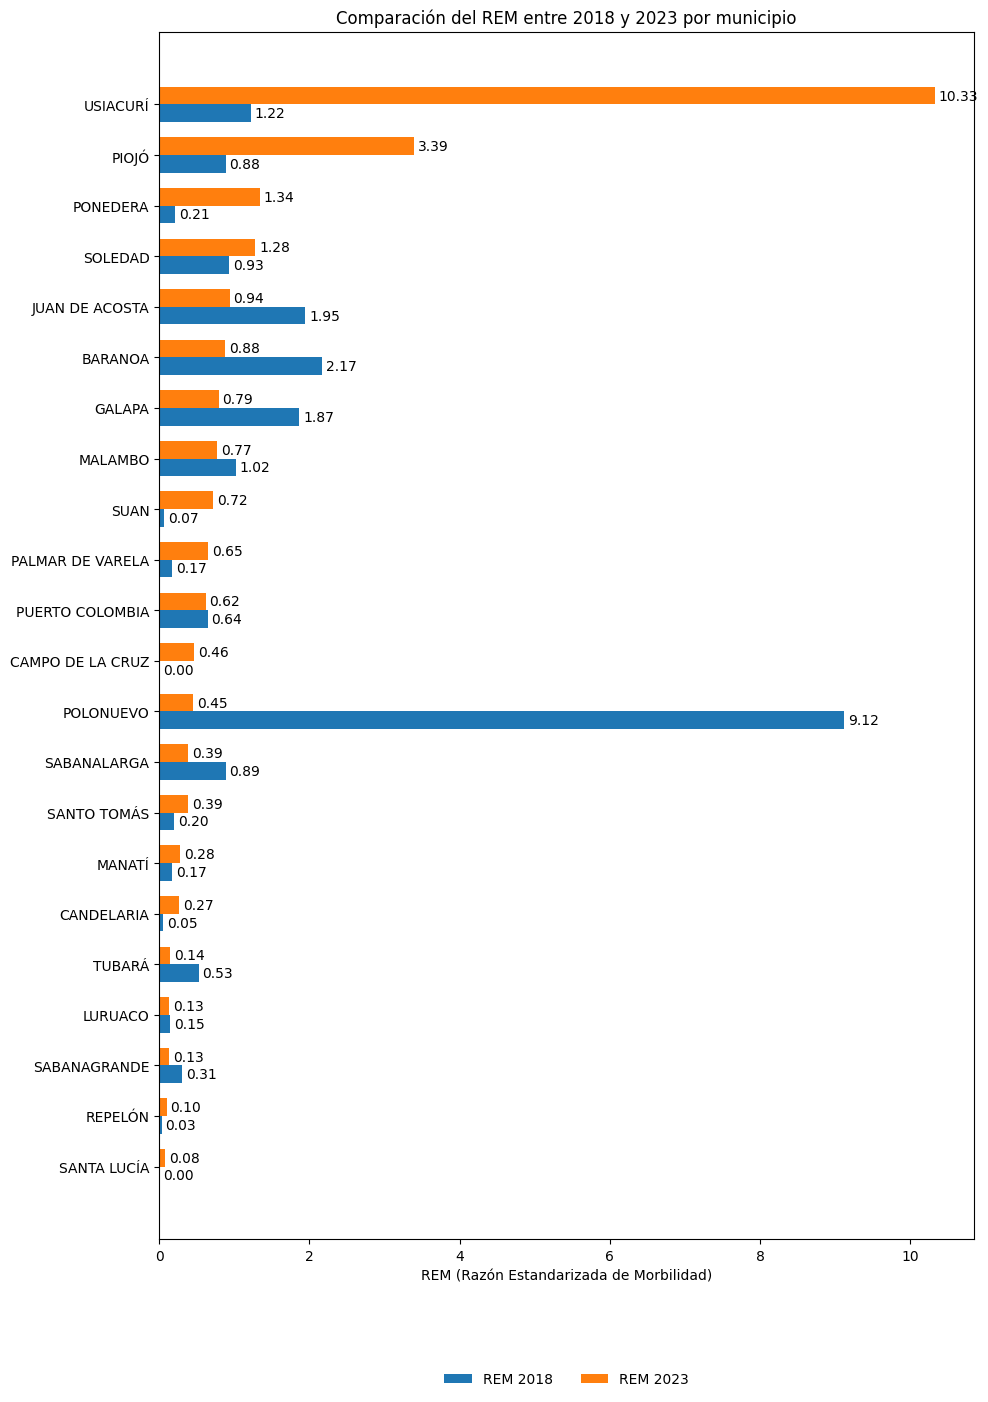

In [7]:


plt.figure(figsize=(10, 14))

# Más separación entre barras
bar_height = 0.35
y_positions = range(len(municipios))

# Barras 2018 (abajo)
plt.barh(
    [y - bar_height/2 for y in y_positions],
    rem18,
    height=bar_height,
    label="REM 2018"
)

# Barras 2023 (arriba)
plt.barh(
    [y + bar_height/2 for y in y_positions],
    rem23,
    height=bar_height,
    label="REM 2023"
)

# Etiquetas numéricas
for i, v in enumerate(rem18):
    plt.text(v + 0.05, i - bar_height/2, f"{v:.2f}", va="center")

for i, v in enumerate(rem23):
    plt.text(v + 0.05, i + bar_height/2, f"{v:.2f}", va="center")

plt.yticks(list(y_positions), municipios)
plt.xlabel("REM (Razón Estandarizada de Morbilidad)")
plt.title("Comparación del REM entre 2018 y 2023 por municipio")

# Leyenda debajo del gráfico
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()